In [ ]:
!pip install gdown

In [2]:
!gdown --id 1219EeGE1XTJVXYaulynJSa3BXGsbNCLx -O Archive.zip

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1219EeGE1XTJVXYaulynJSa3BXGsbNCLx
From (redirected): https://drive.google.com/uc?id=1219EeGE1XTJVXYaulynJSa3BXGsbNCLx&confirm=t&uuid=fa145325-6ccb-4609-8827-5c1fe3ee96ce
To: /content/Archive.zip
100% 1.23G/1.23G [00:16<00:00, 75.8MB/s]


In [ ]:
!unzip -o Archive.zip

In [4]:
!ls

Archive.zip  __MACOSX  sample_data  test  train  val


In [5]:
!ls train

NORMAL	PNEUMONIA


In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Input
import matplotlib.pyplot as plt


In [7]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train = train_datagen.flow_from_directory(
    'train',
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val = train_datagen.flow_from_directory(
    'train',
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

test = test_datagen.flow_from_directory(
    'test',
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [8]:
model = Sequential()

model.add(Input(shape=(150,150,3)))

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,377 (18.42 MB)

 Trainable params: 4,828,929 (18.42 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


In [10]:
history = model.fit(
    train,
    epochs=10,
    validation_data=val,
    callbacks=[early_stop]
)


Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 98s 678ms/step - accuracy: 0.8783 - loss: 0.3685 - val_accuracy: 0.7430 - val_loss: 5.2543
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 128s 623ms/step - accuracy: 0.9097 - loss: 0.2174 - val_accuracy: 0.7430 - val_loss: 7.3488
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 81s 616ms/step - accuracy: 0.9243 - loss: 0.1897 - val_accuracy: 0.7430 - val_loss: 3.9130
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 80s 612ms/step - accuracy: 0.9331 - loss: 0.1787 - val_accuracy: 0.7929 - val_loss: 0.7372
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 81s 621ms/step - accuracy: 0.9358 - loss: 0.1720 - val_accuracy: 0.9329 - val_loss: 0.1651
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 85s 649ms/step - accuracy: 0.9396 - loss: 0.1686 - val_accuracy: 0.8734 - val_loss: 0.2472
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 81s 621ms/step - accuracy: 0.9396 - loss: 0.1671 - val_accuracy: 0.9521 - val_loss: 0.1350
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 80s 612ms/step - accuracy: 0.9434 - loss: 

In [11]:
loss, acc = model.evaluate(test)
print("Test Accuracy:", acc)


20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 276ms/step - accuracy: 0.9054 - loss: 0.2740
Test Accuracy: 0.9054487347602844


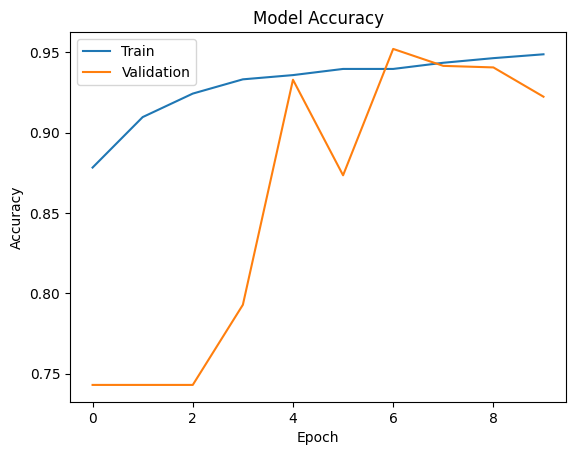

In [12]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()



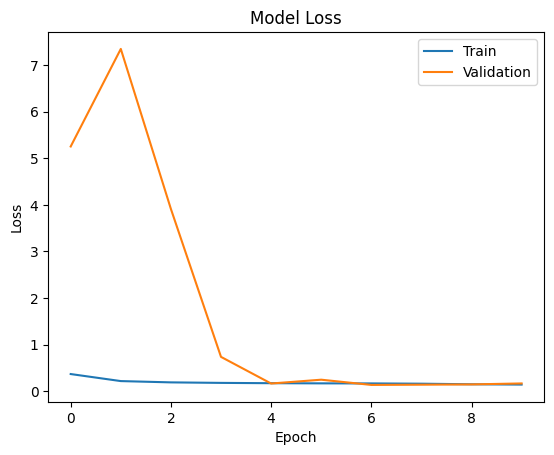

In [13]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()
